# Лабораторная работа: Решение СЛАУ

- Студент: Платов Дмитрий Константинович
- Группа: 6
- Дата: 12.05.26

### Цель работы
Изучение методов решения СЛАУ.

<br><br>
### Ход работы

### 0. Инициализация исходной матрицы коэффициентов и импорт необходимых библиотек

In [88]:
import timeit

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(0)
A = np.array([
    [8, -1, -1, 2],
    [1, 6, -2, -2],
    [2, 1, -5, 1],
    [1, -1, 1, -4],
])

B = np.array([
    11, -7, 2, -2
])

answer = np.array([1, -1, 0, 1])

### 1. Создание функций, реализующих прямые методы решения СЛАУ

In [89]:
def LU_decomposition_method(A: np.ndarray, B: np.ndarray):
    n = A.shape[0]
    L = np.zeros((n, n))
    U = np.identity(n)

    for i in range(n):
        # для L: i - номер столбца 
        for j in range(i, n):
            L[j, i] = A[j, i] - np.sum(L[j, :i] * U[:i, i])

        for j in range(i, n):
            if i == j:
                U[i, j] = 1
                continue
            U[i, j] = (A[i, j] - np.sum(L[i, :i] * U[:i, j])) / L[i, i]

    y = np.zeros(n)
    for i in range(n):
        y[i] = (B[i] - np.sum(L[i, :i] * y[:i])) / L[i, i]

    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.sum(U[i, i + 1:] * x[i + 1:])) / U[i, i]
    return x

### 2. Анализ скорости работы алгоритма прямого решение СЛАУ. Сравнение с аналитическим решением

In [98]:
solution = LU_decomposition_method(A, B)

df_comparison = pd.DataFrame({
    'Переменная': [f'x{i + 1}' for i in range(4)],
    'Аналитическое': answer,
    'LU решение': np.round(solution, 6),
    'Совпадают': np.isclose(solution, answer)
})

exec_time = timeit.timeit(
    stmt='LU_decomposition_method(A, B)',
    globals=globals(),
    number=10000
) / 10000

df_time = pd.DataFrame({
    'Метрика': ['Среднее время (сек)', 'Среднее время (мс)'],
    'Значение': [f'{exec_time:.8f}', f'{exec_time * 1000:.4f}']
})

print("=== Сравнение с аналитическим решением ===")
print(df_comparison.to_string(index=False))
print()
print("=== Анализ скорости работы алгоритма ===")
print(df_time.to_string(index=False))

=== Сравнение с аналитическим решением ===
Переменная  Аналитическое  LU решение  Совпадают
        x1              1         1.0       True
        x2             -1        -1.0       True
        x3              0         0.0       True
        x4              1         1.0       True

=== Анализ скорости работы алгоритма ===
            Метрика   Значение
Среднее время (сек) 0.00006970
 Среднее время (мс)     0.0697


### 3.  Реализация итерационных алгоритмов решения СЛАУ 

In [93]:
def jacobi_method(A: np.ndarray, B: np.ndarray, EPS: float = 1e-6):
    n = A.shape[0]
    x = np.ones(n, dtype=float)

    it = 0
    while True:
        it += 1
        x_old = x.copy()
        x_new = np.zeros(n)

        for i in range(n):
            x_new[i] = (B[i] - (np.sum(A[i] * x_old) - A[i, i] * x_old[i])) / A[i, i]

        diff = np.sqrt(np.sum((x_new - x_old) ** 2))
        x = x_new

        if diff <= EPS:
            break

    return x, it


def gauss_seidel_method(A: np.ndarray, B: np.ndarray, EPS: float = 1e-6):
    n = A.shape[0]
    x = np.ones(n, dtype=float)

    it = 0
    while True:
        it += 1
        x_old = x.copy()

        for i in range(n):
            x[i] = (B[i] - (np.sum(A[i] * x) - A[i, i] * x[i])) / A[i, i]

        diff = np.sqrt(np.sum((x - x_old) ** 2))

        if diff <= EPS:
            break

    return x, it

### 4. Анализ скорости и точности работы итерационных методов 

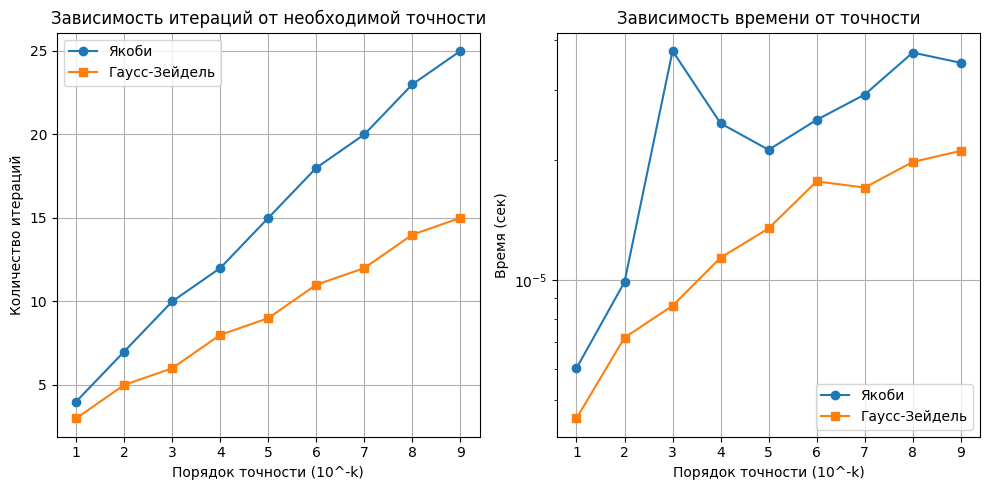

In [94]:
eps_values = [10 ** (-k) for k in range(1, 10)]
jacobi_iters = []
gauss_iters = []

for eps in eps_values:
    _, it_j = jacobi_method(A, B, eps)
    _, it_g = gauss_seidel_method(A, B, eps)
    jacobi_iters.append(it_j)
    gauss_iters.append(it_g)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 10), jacobi_iters, marker='o', label='Якоби')
plt.plot(range(1, 10), gauss_iters, marker='s', label='Гаусс-Зейдель')
plt.xlabel('Порядок точности (10^-k)')
plt.ylabel('Количество итераций')
plt.title('Зависимость итераций от необходимой точности')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
jacobi_times = []
gauss_times = []
for eps in eps_values:
    t_j = timeit.timeit(lambda: jacobi_method(A, B, eps), number=1000) / 10000
    t_g = timeit.timeit(lambda: gauss_seidel_method(A, B, eps), number=1000) / 10000
    jacobi_times.append(t_j)
    gauss_times.append(t_g)

plt.semilogy(range(1, 10), jacobi_times, 'o-', label='Якоби')
plt.semilogy(range(1, 10), gauss_times, 's-', label='Гаусс-Зейдель')
plt.xlabel('Порядок точности (10^-k)')
plt.ylabel('Время (сек)')
plt.title('Зависимость времени от точности')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Создание функции реализующей алгоритм метода Якоби в матричном виде

In [109]:
def jacobi_method_matrix_form(A: np.ndarray, B: np.ndarray, EPS: float = 1e-6):
    n = A.shape[0]
    D = np.diagflat(np.diag(A))
    D_inv = np.diagflat(1 / np.diag(A))

    x = np.ones(n)
    it = 0
    while True:
        it += 1
        x_old = x.copy()

        x = D_inv @ B - D_inv @ (A - D) @ x_old

        diff = np.sqrt(np.sum((x - x_old) ** 2))

        if diff <= EPS:
            break

    return x, it

### 6. Сравнение скорости работы матричной и поэлементной реализаций метода Якоби

In [110]:
EPS = 1e-6
time_loop = timeit.timeit(lambda: jacobi_method(A, B, EPS), number=10000) / 10000
time_matrix = timeit.timeit(lambda: jacobi_method_matrix_form(A, B, EPS), number=10000) / 10000

df_comparison = pd.DataFrame({
    'Реализация': ['Покомпонентная (циклы)', 'Матричная (векторизованная)'],
    'Среднее время (сек)': [f'{time_loop:.8f}', f'{time_matrix:.8f}'],
    'Среднее время (мс)': [f'{time_loop * 1000:.4f}', f'{time_matrix * 1000:.4f}'],
    'Ускорение': [f'1.00x', f'{time_loop / time_matrix:.2f}x']
})

print("=== Сравнение скорости работы метода Якоби ===")
print(df_comparison.to_string(index=False))

=== Сравнение скорости работы метода Якоби ===
                 Реализация Среднее время (сек) Среднее время (мс) Ускорение
     Покомпонентная (циклы)          0.00028036             0.2804     1.00x
Матричная (векторизованная)          0.00012338             0.1234     2.27x


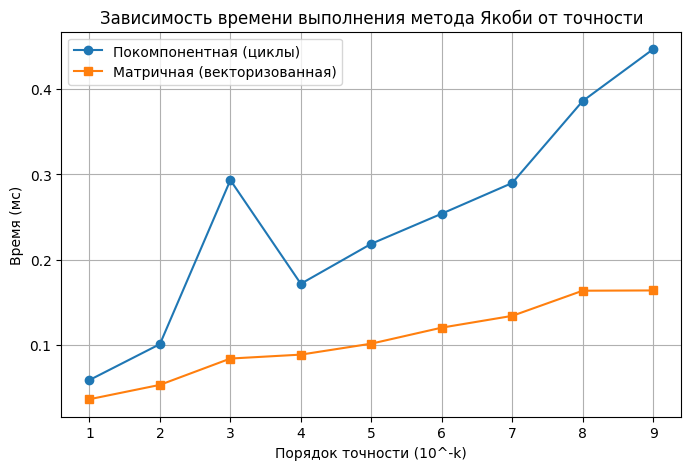

In [112]:
eps_values = [10 ** (-k) for k in range(1, 10)]

loop_times = []
matrix_times = []

for eps in eps_values:
    t_loop = timeit.timeit(lambda: jacobi_method(A, B, eps), number=1000) / 1000
    t_matrix = timeit.timeit(lambda: jacobi_method_matrix_form(A, B, eps), number=1000) / 1000
    loop_times.append(t_loop * 1000)
    matrix_times.append(t_matrix * 1000)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), loop_times, 'o-', label='Покомпонентная (циклы)')
plt.plot(range(1, 10), matrix_times, 's-', label='Матричная (векторизованная)')
plt.xlabel('Порядок точности (10^-k)')
plt.ylabel('Время (мс)')
plt.title('Зависимость времени выполнения метода Якоби от точности')
plt.legend()
plt.grid(True)
plt.show()

### 7. Выводы

- Прямой метод LU-разложения даёт точное решение за фиксированное число операций и не зависит от свойств матрицы, однако при больших размерностях может быть вычислительно затратным. Итерационные методы (Якоби и Гаусса-Зейделя) требуют меньше памяти, но их сходимость напрямую зависит от свойств матрицы.

- Метод Гаусса-Зейделя показал более высокую скорость сходимости: для достижения точности 10^(-9) ему потребовалось около 15 итераций, тогда как методу Якоби - около 25 итераций. Это объясняется тем, что в методе Гаусса-Зейделя каждая компонента вектора обновляется с использованием уже вычисленных значений на текущей итерации, что ускоряет сходимость. Соответственно, время выполнения метода Гаусса-Зейделя также оказалось меньше.

- Матричная (векторизованная) реализация метода Якоби, использующая операции библиотеки NumPy, оказалась примерно в 2.13 раза быстрее поэлементной реализации с вложенными циклами. Для матрицы размером 4*4 ускорение не является критическим, однако для систем большей размерности преимущество матричного подхода становится существенным за счёт использования оптимизированных линейных алгебраических операций.

